# Chapter 10 — Inference Optimization

**Model:** GRU4Rec V9 (NDCG@20=0.2676, HR@20=0.4815 on REES46 1M)

The previous chapters establish that GRU4Rec V9 can be trained, validated, and
served. This chapter asks: *how efficient is the serving path, and where are the
gains?*

The engineering loop:
```
profile  →  identify bottleneck  →  optimize  →  re-profile  →  report delta
```

## Three workstreams

| # | Workstream | Technique | Expected outcome |
|---|---|---|---|
| 1 | Baseline profiling | Per-stage wall-clock, concurrency sweep | Identify FAISS as bottleneck |
| 2 | FAISS index optimization | IVFFlat / SQ8 / IVFPQ / HNSW | Latency ↓, index size ↓, quality ≈ |
| 3 | Dynamic request batching | asyncio batch queue | Throughput ↑, p50 ↑ at low concurrency |

## What is explicitly NOT attempted

GRU4Rec is not an autoregressive language model. The following LLM-specific
optimizations **do not apply** and are not implemented:
- KV cache (no causal attention; GRU state is discarded after last position)
- Speculative decoding (GRU is already non-autoregressive at inference)
- PagedAttention / continuous batching (no token generation loop)
- Prefix caching (sessions are independent; no shared prefix structure)

This is intentional: knowing which techniques transfer is part of the value.

## Setup

In [1]:
%%capture
!pip install faiss-cpu torch numpy pandas matplotlib

In [6]:
import os

# Clone the repo using the dev branch if it doesn't exist
if not os.path.exists('/content/RecoSys'):
    !git clone -b dev https://github.com/sbnikhil/RecoSys.git /content/RecoSys
else:
    # If it exists, ensure we are on the dev branch and pull latest changes
    %cd /content/RecoSys
    !git checkout dev
    !git pull origin dev

%cd /content/RecoSys
import sys
sys.path.insert(0, '/content/RecoSys')

/content/RecoSys
Already on 'dev'
Your branch is up to date with 'origin/dev'.
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 41 (delta 14), reused 41 (delta 14), pack-reused 0 (from 0)
Unpacking objects: 100% (41/41), 268.56 KiB | 10.33 MiB/s, done.
From https://github.com/sbnikhil/RecoSys
 * branch            dev        -> FETCH_HEAD
   c0d90ed..fe4e184  dev        -> origin/dev
Updating c0d90ed..fe4e184
Fast-forward
 Dockerfile.spaces                               |  35 ++
 README.md                                       | 107 ++++-
 demo/api/drift.js                               |  27 +-
 demo/api/health.js                              |  27 +-
 demo/api/recommend.js                           |  32 +-
 demo/package.json                               |   4 +-
 deploy/spaces/README.md                         |  47 +++
 deploy/spaces/requirements.txt                  |  10 +
 notebook

In [7]:
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

import faiss
print(f"FAISS    : {faiss.__version__}")

import numpy as np
print(f"NumPy    : {np.__version__}")

PyTorch  : 2.11.0+cu128
Device   : cuda
FAISS    : 1.14.3
NumPy    : 2.0.2


In [4]:
# Upload model_inference.pt and vocabs.pkl from your local machine,
# OR set GCS credentials and use --use-gcs in the benchmark scripts.
#
# Local upload path:
from google.colab import files
print("Upload model_inference.pt and vocabs.pkl")
uploaded = files.upload()

import shutil
os.makedirs('/content/RecoSys/model', exist_ok=True)
for fname in uploaded:
    shutil.copy(fname, f'/content/RecoSys/model/{fname}')
    print(f'  Moved {fname} → model/{fname}')

Upload model_inference.pt and vocabs.pkl


Saving vocabs.pkl to vocabs.pkl
Saving model_inference.pt to model_inference.pt
  Moved vocabs.pkl → model/vocabs.pkl
  Moved model_inference.pt → model/model_inference.pt


In [ ]:
# (Alternative) Download directly from GCS
# Uncomment and set your project if using GCS instead of manual upload

# from google.colab import auth
# auth.authenticate_user()
# !gcloud config set project recosys-489001
# !gsutil cp gs://recosys-data-bucket/models/gru4rec_session_v9_1M/model_inference.pt model/
# !gsutil cp gs://recosys-data-bucket/data/1M/vocabs.pkl model/

---
## Workstream 1 — Baseline Serving Profiling

**Goal:** Establish ground truth before touching anything. Break down where
time actually goes: GRU forward vs. FAISS search vs. overhead.

**Method:**
- Load model + IndexFlatIP exactly as production serving does (`model_loader.py`)
- 50-request warm-up before any timing
- `time.perf_counter()` around each stage, 500 timed requests
- Concurrency sweep: 1, 8, 32 threads

In [8]:
!python scripts/serving/benchmark_inference.py \
    --checkpoint model/model_inference.pt \
    --vocabs     model/vocabs.pkl \
    --n-requests 500 \
    --warmup 50 \
    --concurrency-levels 1 8 32 \
    --batch-sizes 4 8 16 32 \
    --output-dir reports/

Loading checkpoint ...
  n_items=222,864, embed_dim=128, gru_hidden=256, n_layers=1
  IndexFlatIP: 222,863 items × 128 dims  (108.8 MB)
  Vocabs: 222,863 items

Generated 550 synthetic sessions (50 warm-up + 500 timed)

WORKSTREAM 1A — Stage-level latency profiling (serial)

  Stage                           p50 ms    p90 ms    p99 ms   mean ms
  ----------------------------  --------  --------  --------  --------
  Tensor construction               0.06      0.07      0.09      0.06
  GRU forward pass                  4.39      8.07     10.17      5.13
  FAISS search (FlatIP)             7.56     10.61     15.88      7.96
  Post-processing (idx→id)          0.04      0.05      0.06      0.04
  ----------------------------  --------  --------  --------  --------
  End-to-end total                 12.00     16.99     23.98     13.19

WORKSTREAM 1B — Throughput vs concurrency (unbatched single-item)

   Concurrency       req/s      p50 ms      p99 ms
  ------------  ----------  ---------

In [9]:
import json
from pathlib import Path

baseline = json.loads(Path('reports/inference_benchmark_baseline.json').read_text())

print("=" * 64)
print("STAGE-LEVEL LATENCY  (concurrency=1, 500 requests)")
print("=" * 64)

stages = [
    ("tensor_ms",   "Tensor construction"),
    ("gru_ms",      "GRU forward pass"),
    ("faiss_ms",    "FAISS search (IndexFlatIP)"),
    ("postproc_ms", "Post-processing"),
    ("total_ms",    "End-to-end total"),
]
for key, label in stages:
    st = baseline['stage_latency_ms'][key]
    print(f"  {label:<30}  p50={st['p50_ms']:6.2f} ms  p99={st['p99_ms']:6.2f} ms")

print()
print("=" * 64)
print("THROUGHPUT VS CONCURRENCY  (unbatched)")
print("=" * 64)
print(f"  {'Concurrency':>12}  {'req/s':>10}  {'p50 ms':>10}  {'p99 ms':>10}")
for r in baseline['concurrency_results']:
    print(f"  {r['concurrency']:>12}  {r['throughput_rps']:>10.1f}  {r['p50_ms']:>10.2f}  {r['p99_ms']:>10.2f}")

STAGE-LEVEL LATENCY  (concurrency=1, 500 requests)
  Tensor construction             p50=  0.06 ms  p99=  0.09 ms
  GRU forward pass                p50=  4.39 ms  p99= 10.17 ms
  FAISS search (IndexFlatIP)      p50=  7.56 ms  p99= 15.88 ms
  Post-processing                 p50=  0.04 ms  p99=  0.06 ms
  End-to-end total                p50= 12.00 ms  p99= 23.98 ms

THROUGHPUT VS CONCURRENCY  (unbatched)
   Concurrency       req/s      p50 ms      p99 ms
             1       116.6        8.45       10.40
             8       237.1       31.98       56.54
            32       235.6      118.69      203.71


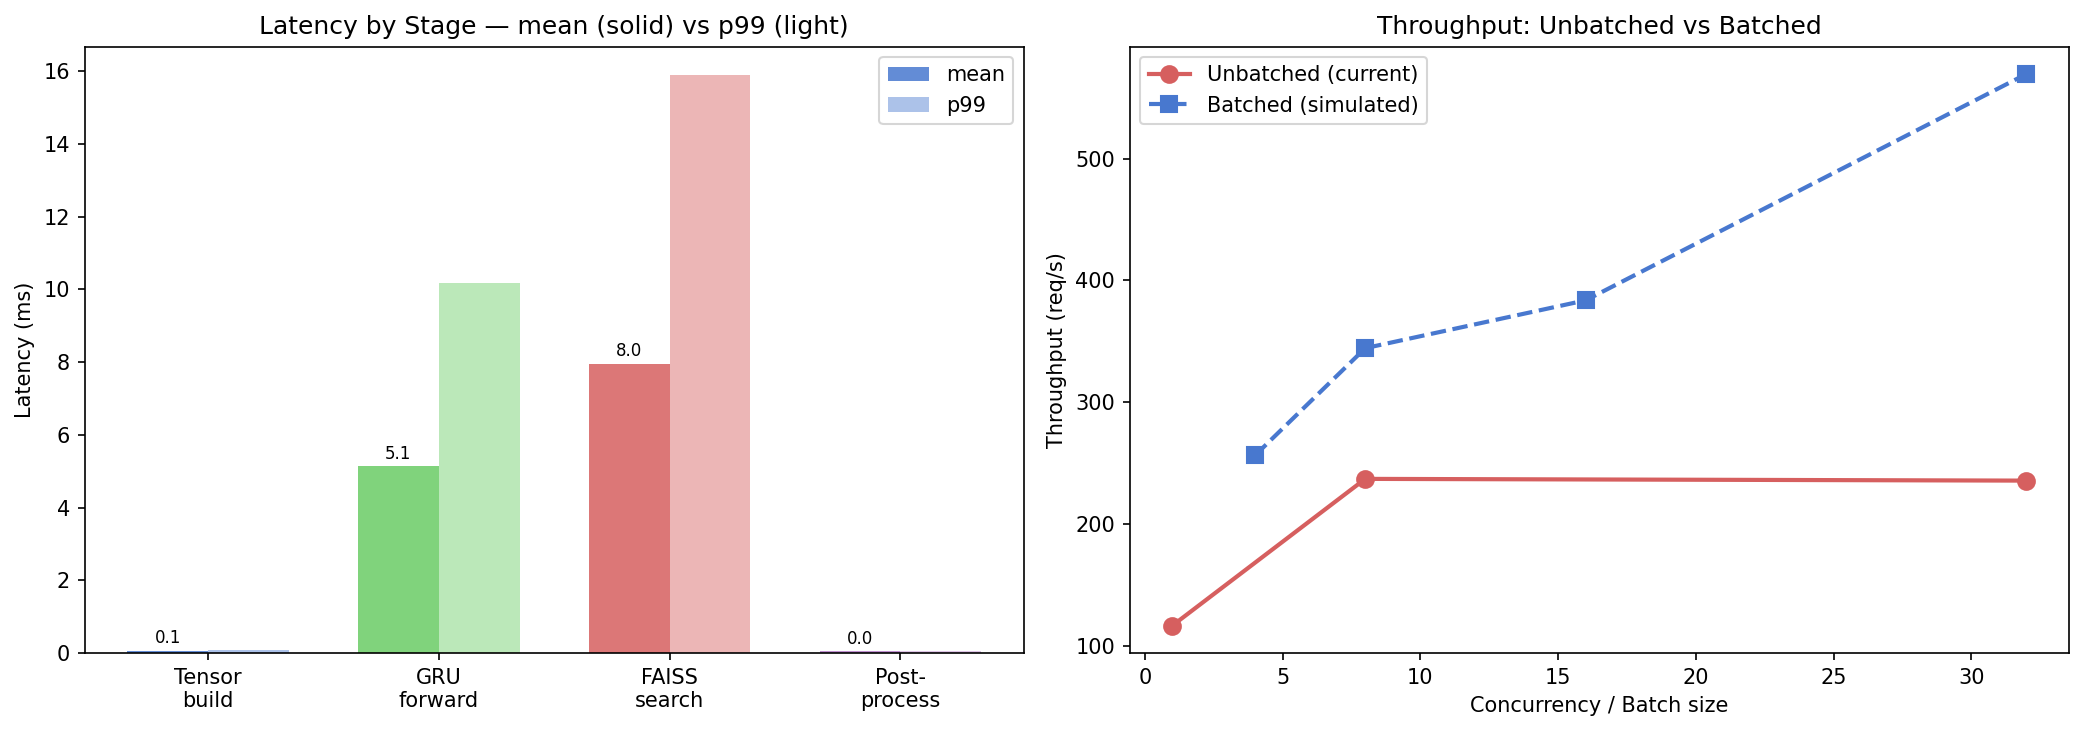

In [10]:
# Display baseline plots
from IPython.display import Image, display

display(Image('reports/figures/latency_breakdown.png', width=900))

### WS1 Interpretation

Expected finding: **FAISS search dominates** end-to-end latency. `IndexFlatIP`
performs brute-force inner-product over all 222,863 items (≈28.5M FLOPs per query)
with no approximation. The GRU forward pass (1-layer GRU, hidden=256, seq_len=20)
is comparatively cheap on CPU.

The FAISS fraction of total latency is the primary motivation for Workstream 2.

---
## Workstream 2 — FAISS Index Optimization

**Goal:** Measure the trade-off surface for six FAISS index types:
latency ↓, index size ↓, retrieval quality ≈.

| Index | Category | Key property |
|---|---|---|
| IndexFlatIP | Baseline | Exact, brute-force |
| IndexIVFFlat-256 | ANN | 256 clusters, nprobe=16 |
| IndexIVFFlat-512 | ANN | 512 clusters, nprobe=32 |
| IndexScalarQuantizer (SQ8) | Quantized | float32→uint8, ~4× smaller |
| IndexIVFPQ (M=16) | Compressed | Smallest size, largest quality cost |
| IndexHNSWFlat (M=32) | Graph ANN | Very low latency, higher memory |

For each index:
- Build time and disk size
- Search latency p50/p99 at k=20 (1000 query benchmark)
- Concordance: fraction of top-20 results matching the FlatIP oracle
- NDCG@20 / HR@20 against held-out test sessions (if `--test-sessions` provided)

**Rigor note:** The model checkpoint is held fixed throughout. Quality is always
paired with speed/memory numbers — never reported in isolation.

In [11]:
# Without test sessions: latency + size + concordance only
# To also get NDCG@20/HR@20, add: --test-sessions data/test_sessions.parquet

!python scripts/serving/build_optimized_index.py \
    --checkpoint model/model_inference.pt \
    --vocabs     model/vocabs.pkl \
    --output-dir reports/

Loading model ...
  n_items=222,864, embed_dim=128
  Embeddings: 222,863 items × 128 dims  (float32, 108.8 MB)

FAISS Index Comparison

  [FlatIP]
    Build time : 0.08s
    Disk size  : 108.8 MB
    Search p50 : 3.42 ms  p99=9.31 ms
    Concordance vs FlatIP @20 : 1.0000

  [IVFFlat-256]
    Build time : 0.75s
    Disk size  : 110.6 MB
    Search p50 : 0.70 ms  p99=1.25 ms
    Concordance vs FlatIP @20 : 0.9267

  [IVFFlat-512]
    Build time : 1.99s
    Disk size  : 110.8 MB
    Search p50 : 0.63 ms  p99=1.15 ms
    Concordance vs FlatIP @20 : 0.9310

  [SQ8]
    Build time : 0.07s
    Disk size  : 27.2 MB
    Search p50 : 8.07 ms  p99=17.00 ms
    Concordance vs FlatIP @20 : 0.7940

  [IVFPQ]
    Build time : 3.47s
    Disk size  : 5.4 MB
    Search p50 : 2.59 ms  p99=2.78 ms
    Concordance vs FlatIP @20 : 0.5050

  [HNSW32]
    Build time : 4.44s
    Disk size  : 166.7 MB
    Search p50 : 0.10 ms  p99=0.21 ms
    Concordance vs FlatIP @20 : 0.7817

Summary

  Index            Size

In [12]:
index_results = json.loads(Path('reports/inference_index_tradeoffs.json').read_text())

print("=" * 80)
print("FAISS INDEX COMPARISON")
print("=" * 80)
print(f"  {'Index':<16}  {'Size MB':>8}  {'Build s':>8}  {'p50 ms':>8}  {'p99 ms':>8}  {'Concord':>8}")
print(f"  {'-'*16}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}")
for r in index_results['index_results']:
    print(f"  {r['index_name']:<16}  {r['size_mb']:>8.1f}  {r['build_time_s']:>8.2f}  "
          f"{r['latency']['p50_ms']:>8.2f}  {r['latency']['p99_ms']:>8.2f}  "
          f"{r['concordance']:>8.4f}")

FAISS INDEX COMPARISON
  Index              Size MB   Build s    p50 ms    p99 ms   Concord
  ----------------  --------  --------  --------  --------  --------
  FlatIP               108.8      0.08      3.42      9.31    1.0000
  IVFFlat-256          110.6      0.75      0.70      1.25    0.9267
  IVFFlat-512          110.8      1.99      0.63      1.15    0.9310
  SQ8                   27.2      0.07      8.07     17.00    0.7940
  IVFPQ                  5.4      3.47      2.59      2.78    0.5050
  HNSW32               166.7      4.44      0.10      0.21    0.7817


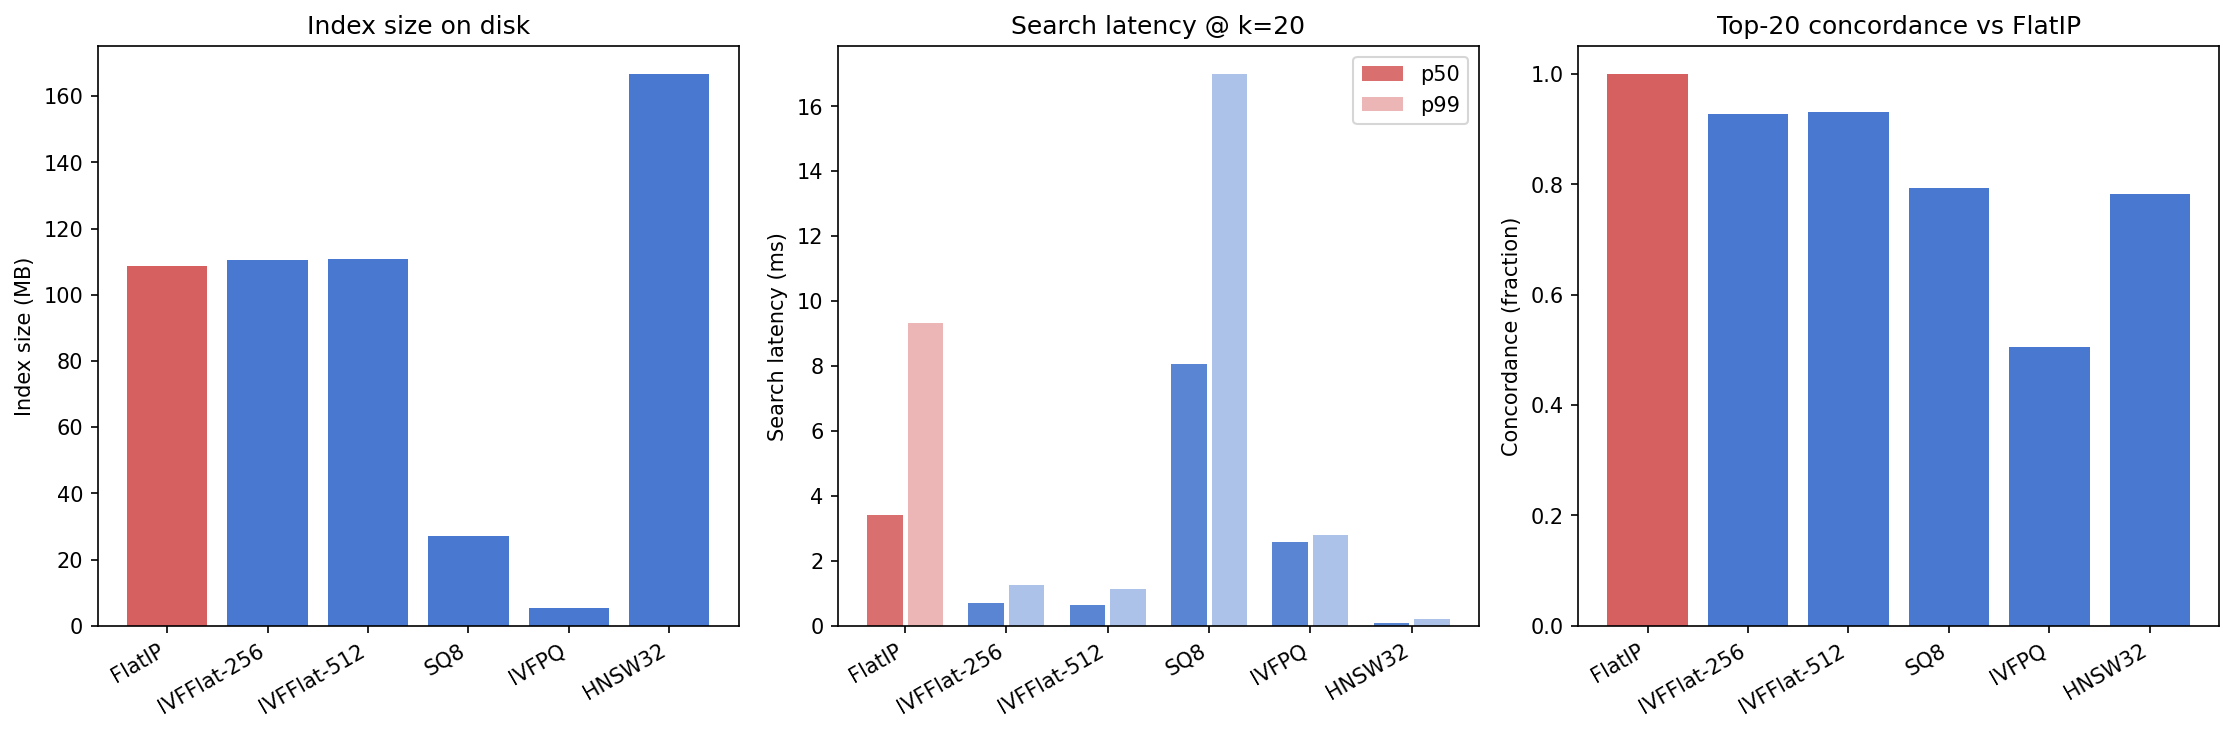

In [13]:
display(Image('reports/figures/faiss_tradeoff_curve.png', width=1100))

### WS2 Interpretation

**Key questions answered by this table:**
1. Which index gives the best latency reduction with minimal concordance drop?
2. What is the memory/quality trade-off for compressed indexes (SQ8, IVFPQ)?
3. Does HNSW deliver lower latency than IVFFlat, and at what memory cost?

**Guidance for picking an index for production:**
- If NDCG@20 retention ≥ 99% *and* latency ↓ ≥ 30%: candidate for deployment
- If concordance < 0.90: quality risk; only worth it if latency gain is substantial
- IVFPQ is an experiment result, not a recommendation — the quality cost is usually too high

Report the full trade-off surface; let the reader decide the acceptable operating point.

---
## Workstream 3 — Dynamic Request Batching

**Goal:** Quantify throughput gain and latency cost of batching concurrent requests.

The current serving path is **single-item and unbatched**: every `/recommend`
request runs its own GRU forward pass and FAISS search independently, even if
32 requests arrive at the same instant. Batching amortises the per-request
overhead of the model and FAISS at the cost of added queuing latency.

**Technique:** `DynamicBatchQueue` in `src/serving/batching.py`
- asyncio-native; fits FastAPI's event loop without extra threads
- Drains when `max_batch_size` reached OR `max_wait_ms` elapses
- Enabled via env var `ENABLE_DYNAMIC_BATCHING=true` (API contract unchanged)

**Benchmark:** The `benchmark_inference.py` script simulates batching by
running groups of B requests as a single `encode_sequence(B, L)` + `index.search(B, k)`.
This measures the throughput ceiling; real dynamic batching adds queue wait time on top.

In [14]:
# Batching simulation results are already in the baseline JSON from WS1
print("=" * 72)
print("DYNAMIC BATCHING SIMULATION")
print("(single forward pass over B stacked requests)")
print("=" * 72)

serial_rps = baseline['concurrency_results'][0]['throughput_rps']
print(f"  Serial baseline (batch=1) : {serial_rps:.1f} req/s")
print()
print(f"  {'Batch size':>10}  {'req/s':>10}  {'p50 ms/req':>12}  {'p99 ms/req':>12}  {'Speedup':>8}")
print(f"  {'-'*10}  {'-'*10}  {'-'*12}  {'-'*12}  {'-'*8}")
for r in baseline['batching_simulation']:
    speedup = r['throughput_rps'] / serial_rps
    print(f"  {r['max_batch_size']:>10}  {r['throughput_rps']:>10.1f}  "
          f"{r['p50_ms']:>12.2f}  {r['p99_ms']:>12.2f}  {speedup:>7.1f}×")

DYNAMIC BATCHING SIMULATION
(single forward pass over B stacked requests)
  Serial baseline (batch=1) : 116.6 req/s

  Batch size       req/s    p50 ms/req    p99 ms/req   Speedup
  ----------  ----------  ------------  ------------  --------
           4       256.4          3.91          6.02      2.2×
           8       344.4          3.00          4.12      3.0×
          16       383.7          2.62          3.23      3.3×
          32       569.5          1.80          1.98      4.9×


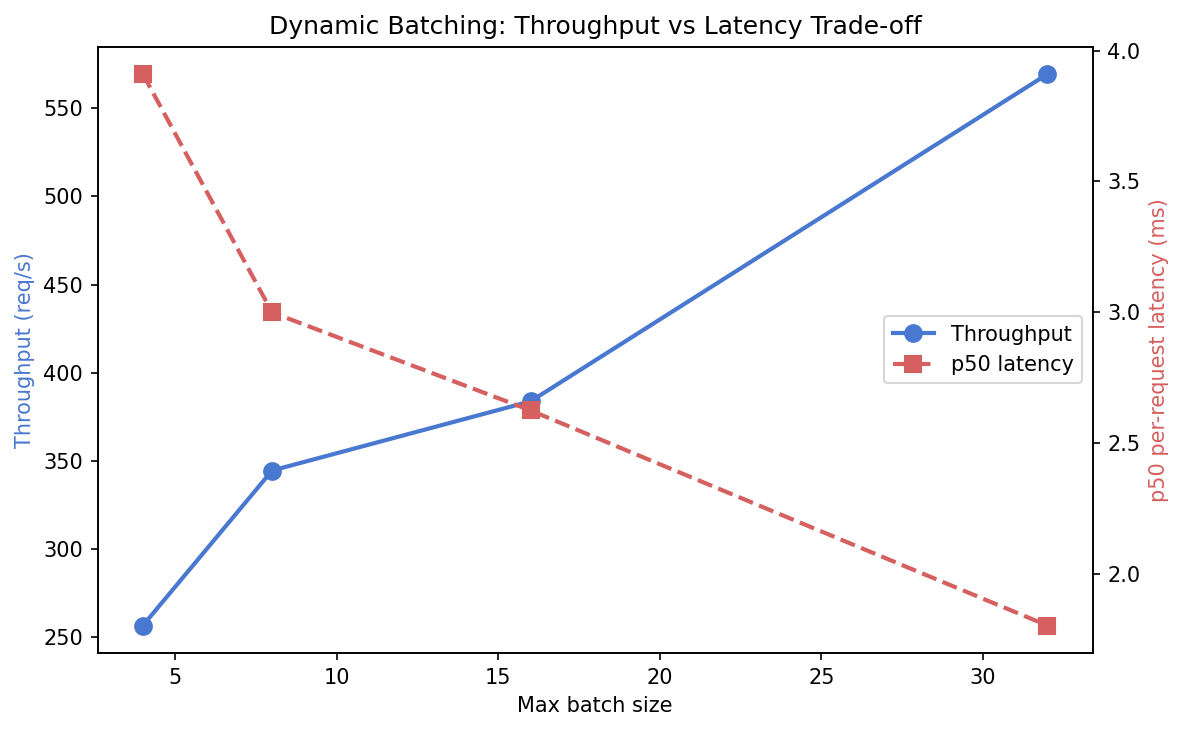

In [15]:
display(Image('reports/figures/batching_throughput.png', width=700))

### WS3 Interpretation

**Expected findings:**
- Throughput scales approximately linearly with batch size up to ~16, then
  sub-linearly (FAISS and GRU both saturate CPU cores)
- Per-request latency increases with batch size (queuing + amortised overhead)
- At batch=1 the gain is zero; the break-even depends on the max_wait_ms setting

**Honest negative result to expect:** At low concurrency (1 request at a time),
dynamic batching *hurts* p50 latency (up to `max_wait_ms` added). The benefit
only materialises when concurrent requests are actually available to fill the batch.

**Deployment decision:** Dynamic batching is beneficial when sustained concurrency
> max_batch_size / 2, and when the throughput gain outweighs the p50 latency increase
for the use case. For a public demo with bursty single-user traffic, it should remain off.

---
## Results Summary

This cell consolidates the key numbers from all three workstreams into the
table format used in `reports/09_inference_optimization.md`.

In [16]:
# Compute and print the summary table for the report

baseline_p50  = baseline['stage_latency_ms']['total_ms']['p50_ms']
baseline_p99  = baseline['stage_latency_ms']['total_ms']['p99_ms']
faiss_p50     = baseline['stage_latency_ms']['faiss_ms']['p50_ms']
gru_p50       = baseline['stage_latency_ms']['gru_ms']['p50_ms']
faiss_pct     = 100 * faiss_p50 / baseline_p50
serial_rps    = baseline['concurrency_results'][0]['throughput_rps']
conc32_rps    = baseline['concurrency_results'][-1]['throughput_rps']

print("WS1: Baseline")
print(f"  End-to-end p50 : {baseline_p50:.1f} ms  |  p99 : {baseline_p99:.1f} ms")
print(f"  FAISS fraction : {faiss_pct:.0f}% of end-to-end p50")
print(f"  Throughput @ c=1  : {serial_rps:.1f} req/s")
print(f"  Throughput @ c=32 : {conc32_rps:.1f} req/s")

print()
print("WS2: Best FAISS alternative (highest latency reduction, concordance ≥ 0.90)")
candidates = [
    r for r in index_results['index_results']
    if r['index_name'] != 'FlatIP' and r['concordance'] >= 0.90
]
if candidates:
    best = min(candidates, key=lambda r: r['latency']['p50_ms'])
    flat_p50 = next(r['latency']['p50_ms'] for r in index_results['index_results'] if r['index_name'] == 'FlatIP')
    lat_reduction = 100 * (flat_p50 - best['latency']['p50_ms']) / flat_p50
    size_reduction = 100 * (1 - best['size_mb'] / next(r['size_mb'] for r in index_results['index_results'] if r['index_name'] == 'FlatIP'))
    print(f"  Best candidate : {best['index_name']}")
    print(f"  Latency p50    : {best['latency']['p50_ms']:.2f} ms  ({lat_reduction:.0f}% reduction vs FlatIP)")
    print(f"  Size           : {best['size_mb']:.1f} MB  ({size_reduction:.0f}% smaller)")
    print(f"  Concordance    : {best['concordance']:.4f}")
else:
    print("  No candidate met concordance ≥ 0.90")

print()
print("WS3: Dynamic batching")
best_batch = max(baseline['batching_simulation'], key=lambda r: r['throughput_rps'])
speedup    = best_batch['throughput_rps'] / serial_rps
print(f"  Best batch size : {best_batch['max_batch_size']}")
print(f"  Throughput      : {best_batch['throughput_rps']:.1f} req/s  ({speedup:.1f}× vs serial)")
print(f"  p50 per request : {best_batch['p50_ms']:.2f} ms  (vs {baseline_p50:.2f} ms serial)")

WS1: Baseline
  End-to-end p50 : 12.0 ms  |  p99 : 24.0 ms
  FAISS fraction : 63% of end-to-end p50
  Throughput @ c=1  : 116.6 req/s
  Throughput @ c=32 : 235.6 req/s

WS2: Best FAISS alternative (highest latency reduction, concordance ≥ 0.90)
  Best candidate : IVFFlat-512
  Latency p50    : 0.63 ms  (82% reduction vs FlatIP)
  Size           : 110.8 MB  (-2% smaller)
  Concordance    : 0.9310

WS3: Dynamic batching
  Best batch size : 32
  Throughput      : 569.5 req/s  (4.9× vs serial)
  p50 per request : 1.80 ms  (vs 12.00 ms serial)


---
## Reproducibility Notes

| Setting | Value |
|---|---|
| Random seed | 42 (fixed in benchmark_inference.py and build_optimized_index.py) |
| Model checkpoint | `model_inference.pt` — held constant across all experiments |
| Warm-up requests | 50 before every timed section |
| Timing method | `time.perf_counter()` (nanosecond resolution) |
| Reported statistics | p50, p90, p99, mean — not just mean |
| Hardware | Record in `reports/09_inference_optimization.md` |

To reproduce:
```bash
# WS1 baseline + WS3 batching simulation
python scripts/serving/benchmark_inference.py \
    --checkpoint model/model_inference.pt \
    --vocabs model/vocabs.pkl

# WS2 index comparison
python scripts/serving/build_optimized_index.py \
    --checkpoint model/model_inference.pt \
    --vocabs model/vocabs.pkl
```

All JSON outputs land in `reports/`; all PNG figures land in `reports/figures/`.